# Checkpoint 2


Dataset de caracteristicas e preço de casas: https://www.kaggle.com/datasets/prokshitha/home-value-insights

# GRUPO (Até 3 pessoas):

Participantes:

*   Matheus Moya de Oliveira      - RM: 562822
*   Daniel Nicolas Leoterio       - RM: 562186
*   Ana Carolina Pereira Fontes   - RM: 562145



## BUSINESS UNDERSTANDING

Construir um modelo que prediga/preveja o preço de venda de um veículo apartir de suas caracteristicas.

## DATA UNDERSTANDING


Exercício 1: Importar dados


In [25]:
import pandas as pd
import os, textwrap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
print("Pasta atual: ", os.getcwd())
print("\nArquivos encontrados:")
for nome in os.listdir("/content"):
  if nome.lower().endswith((".csv", ".txt", ".xlsx")):
    print(" -", nome)

Pasta atual:  /content

Arquivos encontrados:
 - house.csv


In [3]:
caminho = "/content/house.csv"

In [4]:
try:
    df = pd.read_csv(caminho, sep=None, engine="python")
except UnicodeDecodeError:
    df = pd.read_csv(caminho, sep=None, engine="python", encoding="latin-1")
except pd.errors.ParserError:
    df = pd.read_csv(caminho, sep=";")

In [5]:
df_raw = df.copy()

In [6]:
print("Formato (linhas, colunas):", df.shape)
display(df.head(5))
df.info()

Formato (linhas, colunas): (1000, 8)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


### EDA - Análise Exploratória de Dados

Exercício 2: Realizar uma análise exploratória de dados (EDA).

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Square_Footage,1000.0,2815.422000,1255.514921,503.000000,1749.500000,2862.500000,3849.500000,4.999000e+03
Num_Bedrooms,1000.0,2.990000,1.427564,1.000000,2.000000,3.000000,4.000000,5.000000e+00
Num_Bathrooms,1000.0,1.973000,0.820332,1.000000,1.000000,2.000000,3.000000,3.000000e+00
Year_Built,1000.0,1986.550000,20.632916,1950.000000,1969.000000,1986.000000,2004.250000,2.022000e+03
Lot_Size,1000.0,2.778087,1.297903,0.506058,1.665946,2.809740,3.923317,4.989303e+00
Garage_Size,1000.0,1.022000,0.814973,0.000000,0.000000,1.000000,2.000000,2.000000e+00
Neighborhood_Quality,1000.0,5.615000,2.887059,1.000000,3.000000,6.000000,8.000000,1.000000e+01
House_Price,1000.0,618861.018647,253568.058375,111626.853424,401648.228909,628267.291129,827141.277637,1.108237e+06


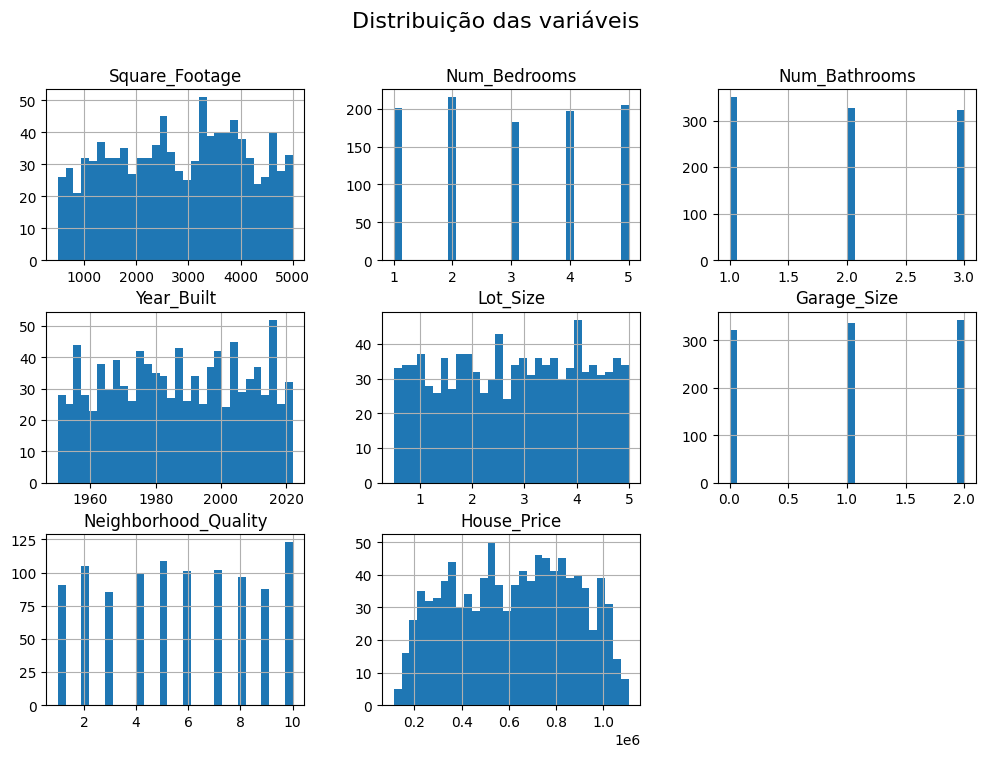

In [8]:
df.hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribuição das variáveis", fontsize=16)
plt.show()

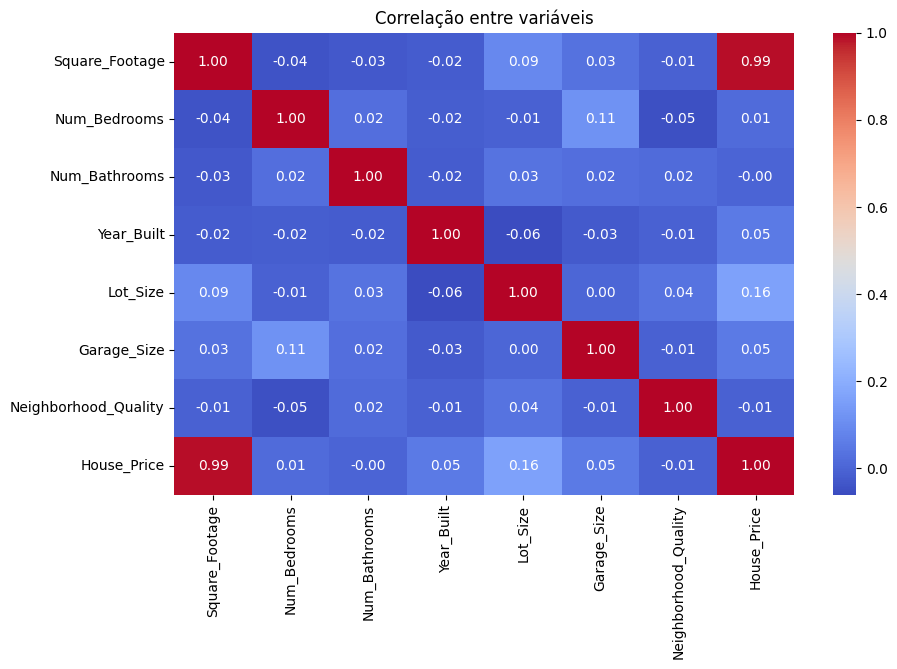

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlação entre variáveis")
plt.show()

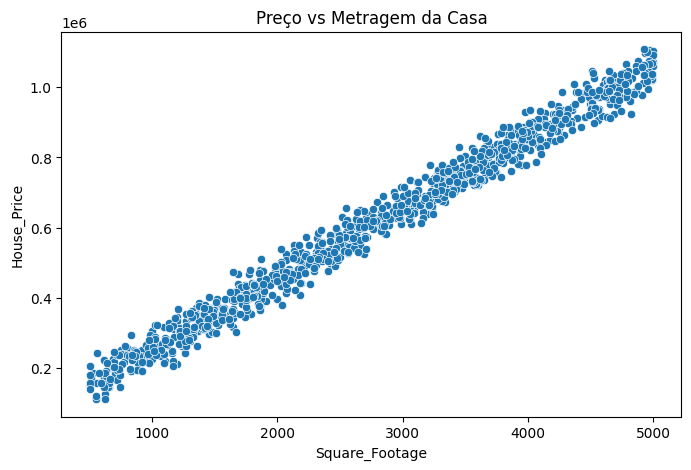

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Square_Footage", y="House_Price", data=df)
plt.title("Preço vs Metragem da Casa")
plt.show()

### Qualidade dos Dados


Exercício 3: Realizar análises de qualidade dos dados.

In [11]:
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.dtypes

,0
Square_Footage,int64
Num_Bedrooms,int64
Num_Bathrooms,int64
Year_Built,int64
Lot_Size,float64
Garage_Size,int64
Neighborhood_Quality,int64
House_Price,float64


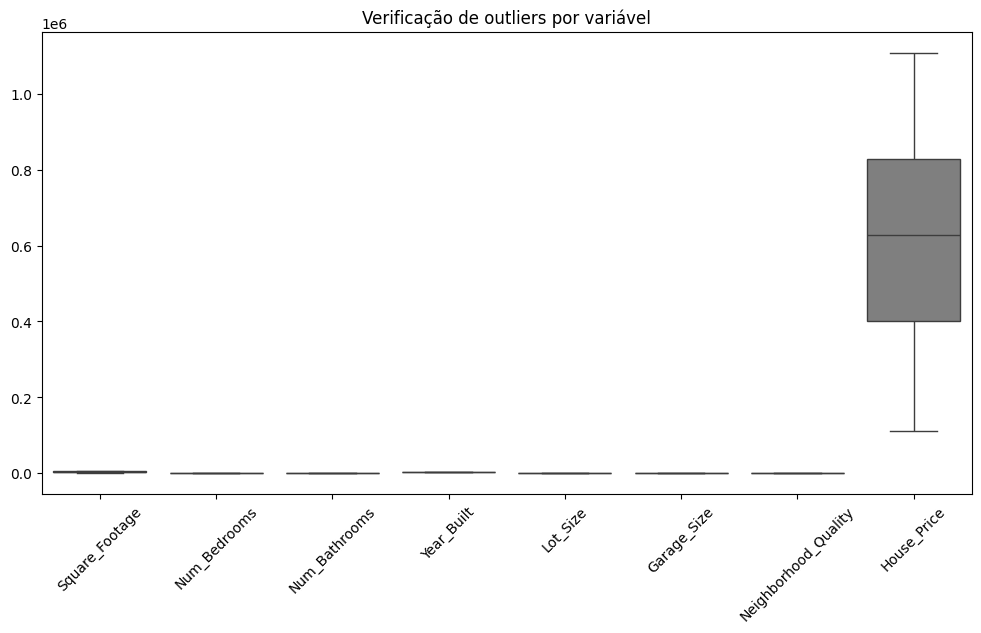

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Verificação de outliers por variável")
plt.show()

## DATA PREPARATION

Exercício 4: Realizar tratamento dos problemas encontrados na Analise de


Qualidade dos Dados.

In [15]:
df_clean = df.copy()

In [16]:
Q1 = df_clean['House_Price'].quantile(0.25)
Q3 = df_clean['House_Price'].quantile(0.75)
IQR = Q3 - Q1

In [17]:
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

In [18]:
df_clean = df_clean[(df_clean['House_Price'] >= limite_inferior) &
                    (df_clean['House_Price'] <= limite_superior)]

print("Formato antes:", df.shape)
print("Formato depois:", df_clean.shape)

Formato antes: (1000, 8)
Formato depois: (1000, 8)


In [19]:
features = df_clean.drop("House_Price", axis=1)
target = df_clean["House_Price"]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("Formato das features escaladas:", features_scaled.shape)

Formato das features escaladas: (1000, 7)


## MODELING

Exercício 5: Realizar a separação dos dados X e y.

In [20]:
X = df_clean.drop("House_Price", axis=1)
y = df_clean["House_Price"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (1000, 7)
Formato de y: (1000,)


Exercício 6: Realizar o treinamento de pelo menos 1 modelos diferentes de Regressão.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
y_pred = modelo_lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Erro Quadrático Médio (MSE):", mse)
print("Coeficiente de Determinação (R²):", r2)

Erro Quadrático Médio (MSE): 101434798.50563568
Coeficiente de Determinação (R²): 0.9984263636823413


O que o modelo aprendeu:

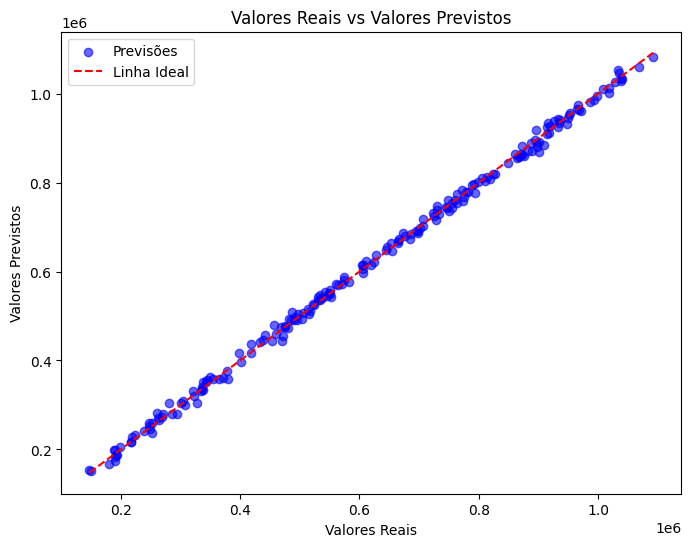

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue", label="Previsões")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linestyle="--", label="Linha Ideal")
plt.xlabel("Valores Reais")
plt.ylabel("Valores Previstos")
plt.title("Valores Reais vs Valores Previstos")
plt.legend()
plt.show()

A linha vermelha mostra o ideal, e os pontos azuis mostram o que o modelo previu. Quanto mais próximo da linha vermelha, melhor o modelo é.

## EVALUATION - AVALIAÇÃO DO MODELO

Exercício 7: Avaliar qual o score do modelo dentre o 3 modelo utilizados.

In [27]:
modelos = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100)
}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)              # treinar
    y_pred = modelo.predict(X_test)           # prever
    r2 = r2_score(y_test, y_pred)             # calcular R²
    mse = mean_squared_error(y_test, y_pred)  # calcular MSE
    print(f"\n{nome}:")
    print(f"  R²: {r2:.4f}")
    print(f"  MSE: {mse:.2f}")


Regressão Linear:
  R²: 0.9984
  MSE: 101434798.51

Árvore de Decisão:
  R²: 0.9850
  MSE: 966529097.47

Random Forest:
  R²: 0.9938
  MSE: 396690279.28


Exercício 8: Realizar a previsao de pelo menos 1 casa desconhecida pelo modelo (pode inventar as caracteristixas da casa).

In [28]:
import numpy as np
nova_casa = np.array([[3500, 4, 3, 2015, 4.0, 2, 8]])
nova_casa_scaled = scaler.transform(nova_casa)

preco_previsto = modelo_lr.predict(nova_casa_scaled)

print(f"Preço previsto para a nova casa: ${preco_previsto[0]:,.2f}")

Preço previsto para a nova casa: $825,986.84


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [38]:
novas_casas = pd.DataFrame([
    [900, 2, 1, 1980, 2.0, 1, 3],     # Casa Popular
    [2000, 3, 2, 2005, 4.0, 2, 6],    # Casa Média
    [4500, 5, 4, 2020, 8.0, 3, 9]     # Casa de Luxo
], columns=features.columns)
previsoes_lr = modelos["Regressão Linear"].predict(novas_casas_scaled)

print("Modelo: Regressão Linear")
for i, preco in enumerate(previsoes_lr, start=1):
    print(f"Casa {i} → Preço previsto: ${preco:,.2f}")

Modelo: Regressão Linear
Casa 1 → Preço previsto: $200,119.07
Casa 2 → Preço previsto: $498,117.83
Casa 3 → Preço previsto: $1,113,704.17


In [39]:
previsoes_lr = modelos["Regressão Linear"].predict(novas_casas_scaled)

tabela_resultados = pd.DataFrame({
    "Casa": ["Casa Popular", "Casa Média", "Casa de Luxo"],
    "Preço Previsto ($)": previsoes_lr
})

display(tabela_resultados.style.format({"Preço Previsto ($)": "${:,.2f}"}))

,Casa,Preço Previsto ($)
0,Casa Popular,"$200,119.07"
1,Casa Média,"$498,117.83"
2,Casa de Luxo,"$1,113,704.17"
